# Naive Baseline Regresi | Prediksi Nilai Kurs USD/IDR (JISDOR)

**Tugas 2, butir 2a**: Target regresi Nilai Penutupan Hari Berikutnya (`kurs_besok`).

Notebook ini mengevaluasi baseline **Persistence (Random Walk)**: prediksi `kurs_besok` hari t = `kurs_jisdor` hari t. Ini baseline standar untuk data FX harian, karena kurs harian mendekati random walk.

Tujuannya: menetapkan *lower bound* RMSE/MAE. Model selanjutnya (ARIMA, XGBoost, model gabungan NLP) harus mengalahkan baseline ini agar dianggap memberi nilai tambah.

In [1]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir() and (candidate / "requirements.txt").exists():
            return candidate
    raise RuntimeError(
        "Repo root tidak ditemukan. Jalankan notebook dari dalam repo "
        "nlp-trio-bertiga (folder manapun di dalamnya)."
    )

REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.models.naive_baseline_regression import (
    predict_persistence_regression,
    evaluate_regression_baseline,
)

print(f"Repo root: {REPO_ROOT}")

C:\Users\Mikail Achmad\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\_param_validation.py:14: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.3)
  from scipy.sparse import csr_matrix, issparse


Repo root: d:\Kuliah\Tugas dan Projek\Pemrosesan Bahasa Alami\repo\nlp-trio-bertiga


## 1. Muat Data Split

In [2]:
SPLIT_DIR = REPO_ROOT / "data" / "split"

train = pd.read_csv(SPLIT_DIR / "train.csv", parse_dates=["tanggal"])
val   = pd.read_csv(SPLIT_DIR / "val.csv",   parse_dates=["tanggal"])
test  = pd.read_csv(SPLIT_DIR / "test.csv",  parse_dates=["tanggal"])

print(f"Train: {len(train)} baris  ({train.tanggal.min().date()} \u2192 {train.tanggal.max().date()})")
print(f"Val  : {len(val)} baris  ({val.tanggal.min().date()} \u2192 {val.tanggal.max().date()})")
print(f"Test : {len(test)} baris  ({test.tanggal.min().date()} \u2192 {test.tanggal.max().date()})")

Train: 959 baris  (2021-09-01 → 2025-08-26)
Val  : 119 baris  (2025-08-28 → 2026-02-19)
Test : 121 baris  (2026-02-23 → 2026-08-31)


## 2. Evaluasi Naive Baseline (Persistence / Random Walk)

In [3]:
results = {}

for split_name, split_df in [("val", val), ("test", test)]:
    y_true = split_df["kurs_besok"].values
    y_pred = predict_persistence_regression(split_df["kurs_jisdor"])

    res = evaluate_regression_baseline(y_true, y_pred, "Persistence (Random Walk)")
    results[split_name] = {"persistence": res}

    print(f"  Split: {split_name.upper()}")
    print(f"  RMSE = {res['rmse']:.4f}   MAE = {res['mae']:.4f}")

  Split: VAL
  RMSE = 37.5053   MAE = 28.5294
  Split: TEST
  RMSE = 57.4694   MAE = 43.5950


## 3. Visualisasi | Prediksi vs Aktual

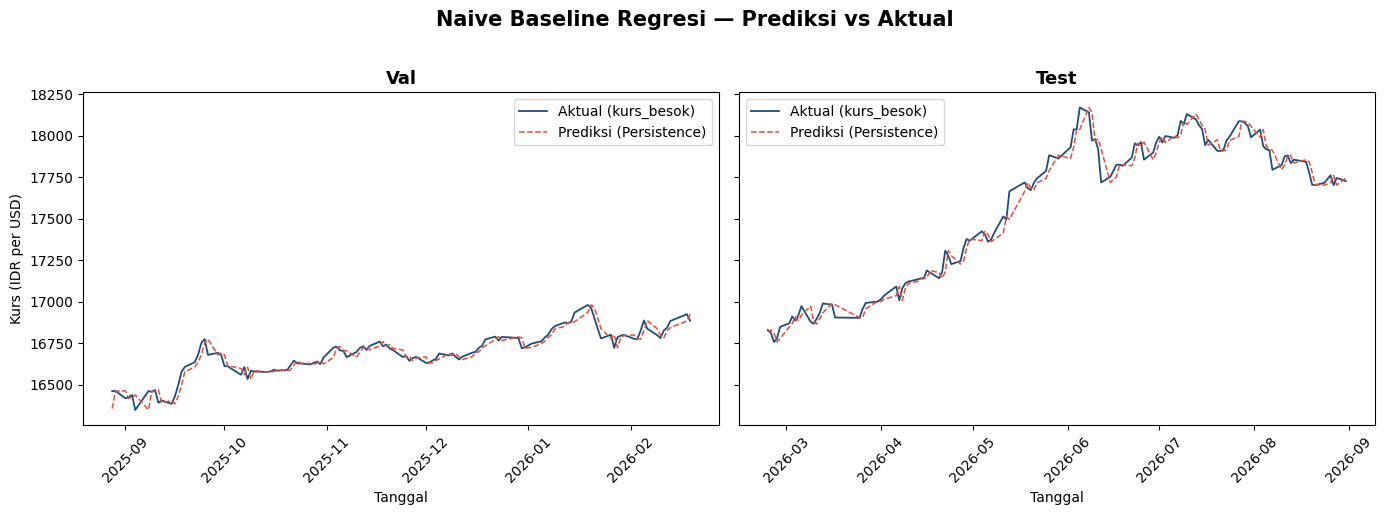

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (split_name, split_df) in zip(axes, [("Val", val), ("Test", test)]):
    y_true = split_df["kurs_besok"]
    y_pred = predict_persistence_regression(split_df["kurs_jisdor"])

    ax.plot(split_df["tanggal"], y_true, label="Aktual (kurs_besok)", color="#1f4e79", linewidth=1.3)
    ax.plot(split_df["tanggal"], y_pred, label="Prediksi (Persistence)", color="#e74c3c", linewidth=1.1, linestyle="--")
    ax.set_title(f"{split_name}", fontweight="bold", fontsize=13)
    ax.set_xlabel("Tanggal")
    ax.tick_params(axis="x", rotation=45)
    ax.legend()

axes[0].set_ylabel("Kurs (IDR per USD)")
fig.suptitle("Naive Baseline Regresi \u2014 Prediksi vs Aktual", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(REPO_ROOT / "results" / "naive_baseline_regression_prediction.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Perbandingan Metrik (RMSE & MAE)

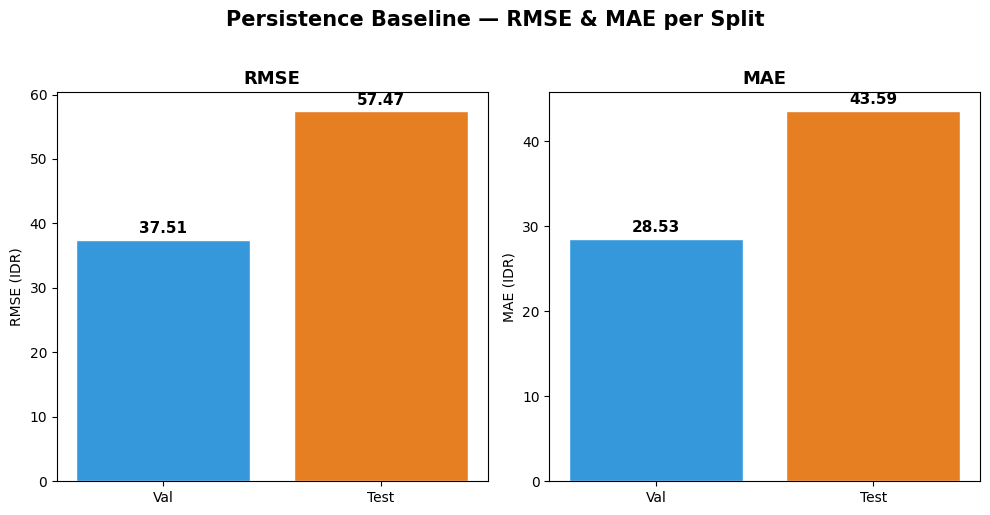

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, metric, label in zip(axes, ["rmse", "mae"], ["RMSE", "MAE"]):
    splits = ["Val", "Test"]
    scores = [results["val"]["persistence"][metric], results["test"]["persistence"][metric]]

    bars = ax.bar(splits, scores, color=["#3498db", "#e67e22"], edgecolor="white")
    for bar, score in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{score:.2f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

    ax.set_ylabel(f"{label} (IDR)")
    ax.set_title(label, fontweight="bold", fontsize=13)

fig.suptitle("Persistence Baseline \u2014 RMSE & MAE per Split", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(REPO_ROOT / "results" / "naive_baseline_regression_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Analisis & Kesimpulan

### Interpretasi

1. RMSE dan MAE baseline Persistence relatif kecil dibanding level kurs (belasan ribu IDR), sesuai ekspektasi untuk data FX harian yang mendekati random walk kurs hari ini adalah prediktor kuat untuk kurs besok tanpa informasi tambahan.
2. RMSE > MAE menunjukkan ada beberapa hari dengan error lebih besar (lonjakan kurs) yang menarik rata-rata kuadrat error ke atas.

### Implikasi untuk Model Selanjutnya

- **Lower bound yang harus dikalahkan**: RMSE dan MAE Persistence baseline di atas.
- Model ARIMA/XGBoost (time-series murni) dan model gabungan (time-series + fitur NLP) harus menghasilkan RMSE/MAE lebih kecil dari baseline ini agar dianggap memberi nilai tambah.

In [6]:
# Simpan ringkasan hasil
summary = {
    "baseline": "Naive Baseline Regresi",
    "strategies": ["Persistence (Random Walk)"],
    "lower_bound_metric": "RMSE",
    "lower_bound_value": results["test"]["persistence"]["rmse"],
    "results": results,
}

with open(REPO_ROOT / "results" / "naive_baseline_regression_results.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("Hasil tersimpan di results/naive_baseline_regression_results.json")
print(f"\nLower bound untuk model selanjutnya: RMSE < {summary['lower_bound_value']:.2f}")

Hasil tersimpan di results/naive_baseline_regression_results.json

Lower bound untuk model selanjutnya: RMSE < 57.47
